# Step 6 time-delay-only prior-volume check

This notebook checks what the Step 6 imaging-only model would infer for H0 when the image-plane likelihood is removed but the time-delay likelihood is retained. This is the relevant prior-volume test for H0: without time delays, H0 is disconnected from the lens model and simply follows its default sampling prior.

The notebook keeps the default uniform cosmology priors from `Step_6_stardm_model_imaging_only_to_hmc.py`, keeps the split-normal `kappa_ext_prior`, keeps the Step 6 mass and point-source priors needed to compute Fermat-potential differences, and removes the image-plane `obs` likelihood. Source pixels and PSF-correction parameters are omitted because they do not enter the time-delay likelihood once the image likelihood is removed.


In [1]:
import os
os.environ.setdefault('HDF5_USE_FILE_LOCKING', 'FALSE')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

try:
    import corner
    HAVE_CORNER = True
except ImportError:
    HAVE_CORNER = False

plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

## Priors copied from the Step 6 imaging-only script

These are the default Step 3 priors in `Step_6_stardm_model_imaging_only_to_hmc.py`. For `kappa_ext`, both the sampling box and the split-normal prior factor are retained.

In [2]:
RNG_SEED = 2033
N_PRIOR_SAMPLES = 100_000

UNIFORM_COSMO_PRIOR = {
    'omega_m_low': 0.05,
    'omega_m_high': 0.55,
    'H0_low': 50.0,
    'H0_high': 150.0,
}

KAPPA_EXT_BOX_PRIOR = {
    'low': -0.20,
    'high': 0.30,
}

KAPPA_EXT_SPLIT_PRIOR = {
    'mean': 0.059,
    'sigma_minus': 0.047,
    'sigma_plus': 0.077,
}

STEP3_PRIOR_BOXES = {
    'm2l_ratio': (0.0, 5.0),
    'm2l_ratio_slope': (-0.6, 0.6),
    'kappa_s_halo': (0.0, 1.0),
    'gammain_halo': (0.6, 2.0),
    'Rs_halo': (2.0, 20.0),
    'gamma_sheer_halo_0': (-0.5, 0.5),
    'gamma_sheer_halo_1': (-0.5, 0.5),
    'kappa_ext': (KAPPA_EXT_BOX_PRIOR['low'], KAPPA_EXT_BOX_PRIOR['high']),
    'theta_E_g1': (0.0, 0.25),
    'theta_E_g2': (0.5, 0.7),
    'omega_m_cosmo': (UNIFORM_COSMO_PRIOR['omega_m_low'], UNIFORM_COSMO_PRIOR['omega_m_high']),
    'H0_cosmo': (UNIFORM_COSMO_PRIOR['H0_low'], UNIFORM_COSMO_PRIOR['H0_high']),
}

STEP3_PRIOR_BOXES

{'m2l_ratio': (0.0, 5.0),
 'm2l_ratio_slope': (-0.6, 0.6),
 'kappa_s_halo': (0.0, 1.0),
 'gammain_halo': (0.6, 2.0),
 'Rs_halo': (2.0, 20.0),
 'gamma_sheer_halo_0': (-0.5, 0.5),
 'gamma_sheer_halo_1': (-0.5, 0.5),
 'kappa_ext': (-0.2, 0.3),
 'theta_E_g1': (0.0, 0.25),
 'theta_E_g2': (0.5, 0.7),
 'omega_m_cosmo': (0.05, 0.55),
 'H0_cosmo': (50.0, 150.0)}

## Reference draw: no time-delay likelihood

This reference draw samples the Step 6 prior boxes and applies the retained `kappa_ext_prior` factor by importance-resampling only `kappa_ext`. It shows the baseline case: if no time-delay likelihood is present, H0 remains exactly its default uniform prior.


In [3]:
def split_normal_logpdf_np(x, mean, sigma_minus, sigma_plus):
    x = np.asarray(x, dtype=float)
    sigma = np.where(x < mean, sigma_minus, sigma_plus)
    log_norm = np.log(np.sqrt(2.0 / np.pi)) - np.log(sigma_minus + sigma_plus)
    return log_norm - 0.5 * ((x - mean) / sigma) ** 2


rng = np.random.default_rng(RNG_SEED)

prior_box_samples = pd.DataFrame({
    name: rng.uniform(low, high, size=N_PRIOR_SAMPLES)
    for name, (low, high) in STEP3_PRIOR_BOXES.items()
})

kappa_logw = split_normal_logpdf_np(
    prior_box_samples['kappa_ext'].values,
    KAPPA_EXT_SPLIT_PRIOR['mean'],
    KAPPA_EXT_SPLIT_PRIOR['sigma_minus'],
    KAPPA_EXT_SPLIT_PRIOR['sigma_plus'],
)
kappa_weight = np.exp(kappa_logw - np.nanmax(kappa_logw))
kappa_weight = kappa_weight / np.nansum(kappa_weight)
kappa_resample_index = rng.choice(N_PRIOR_SAMPLES, size=N_PRIOR_SAMPLES, replace=True, p=kappa_weight)

prior_samples = prior_box_samples.copy()
prior_samples['kappa_ext_box'] = prior_box_samples['kappa_ext'].values
prior_samples['kappa_ext'] = prior_box_samples['kappa_ext'].values[kappa_resample_index]

prior_samples['gamma_ext'] = np.sqrt(prior_samples['gamma_sheer_halo_0']**2 + prior_samples['gamma_sheer_halo_1']**2)

summary_vars = [
    'H0_cosmo',
    'omega_m_cosmo',
    'kappa_ext',
    'm2l_ratio',
    'm2l_ratio_slope',
    'kappa_s_halo',
    'gammain_halo',
    'Rs_halo',
    'gamma_ext',
    'theta_E_g1',
    'theta_E_g2',
]

quantiles = prior_samples[summary_vars].quantile([0.025, 0.16, 0.5, 0.84, 0.975]).T
quantiles.columns = ['q025', 'q16', 'median', 'q84', 'q975']
quantiles['mean'] = prior_samples[summary_vars].mean()
quantiles['std'] = prior_samples[summary_vars].std(ddof=1)
display(quantiles)

print(f"Expected H0 prior median = {(UNIFORM_COSMO_PRIOR['H0_low'] + UNIFORM_COSMO_PRIOR['H0_high']) / 2:.3f}")
print(f"Sampled H0 prior median  = {np.nanmedian(prior_samples['H0_cosmo']):.3f}")
print(f"kappa_ext box-prior median              = {np.nanmedian(prior_samples['kappa_ext_box']):.4f}")
print(f"kappa_ext after split-normal prior median = {np.nanmedian(prior_samples['kappa_ext']):.4f}")

,q025,q16,median,q84,q975,mean,std
H0_cosmo,52.481181,65.923353,100.086528,134.145691,147.533306,100.047999,28.918508
omega_m_cosmo,0.062477,0.129750,0.298995,0.469338,0.536839,0.299402,0.144255
kappa_ext,-0.027372,0.020783,0.077499,0.145253,0.215686,0.082224,0.062287
m2l_ratio,0.125718,0.799340,2.507566,4.200711,4.873621,2.501978,1.444752
m2l_ratio_slope,-0.570617,-0.407101,0.004204,0.407366,0.569391,0.001549,0.345970
kappa_s_halo,0.024704,0.159367,0.496852,0.838360,0.974983,0.498466,0.288713
gammain_halo,0.635718,0.825191,1.300225,1.777131,1.964502,1.300600,0.404144
Rs_halo,2.437996,4.838776,11.022156,17.137171,19.554499,11.000572,5.209663
gamma_ext,0.089343,0.225199,0.398438,0.522943,0.630091,0.382266,0.142696
theta_E_g1,0.006205,0.039930,0.125127,0.210099,0.243741,0.125078,0.072181


Expected H0 prior median = 100.000
Sampled H0 prior median  = 100.087
kappa_ext box-prior median              = 0.0495
kappa_ext after split-normal prior median = 0.0775


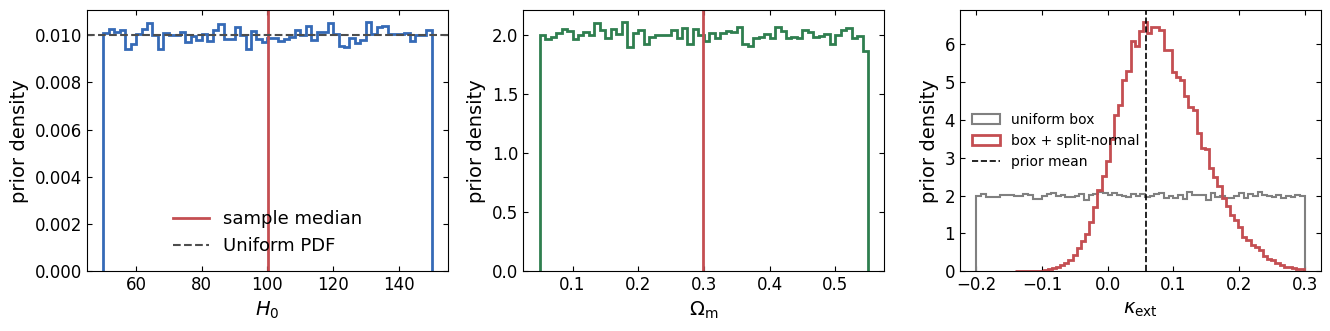

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.5))

ax[0].hist(prior_samples['H0_cosmo'], bins=60, density=True, histtype='step', lw=2, color='#356ab7')
ax[0].axvline(np.nanmedian(prior_samples['H0_cosmo']), color='#c44e52', lw=2, label='sample median')
ax[0].axhline(1.0 / (UNIFORM_COSMO_PRIOR['H0_high'] - UNIFORM_COSMO_PRIOR['H0_low']), color='0.3', ls='--', lw=1.5, label='Uniform PDF')
ax[0].set_xlabel(r'$H_0$')
ax[0].set_ylabel('prior density')
ax[0].legend(frameon=False)

ax[1].hist(prior_samples['omega_m_cosmo'], bins=60, density=True, histtype='step', lw=2, color='#2f7f4f')
ax[1].axvline(np.nanmedian(prior_samples['omega_m_cosmo']), color='#c44e52', lw=2)
ax[1].set_xlabel(r'$\Omega_{\rm m}$')
ax[1].set_ylabel('prior density')

ax[2].hist(prior_samples['kappa_ext_box'], bins=70, density=True, histtype='step', lw=1.5, color='0.5', label='uniform box')
ax[2].hist(prior_samples['kappa_ext'], bins=70, density=True, histtype='step', lw=2, color='#c44e52', label='box + split-normal')
ax[2].axvline(KAPPA_EXT_SPLIT_PRIOR['mean'], color='k', ls='--', lw=1.2, label='prior mean')
ax[2].set_xlabel(r'$\kappa_{\rm ext}$')
ax[2].set_ylabel('prior density')
ax[2].legend(frameon=False, fontsize=10)

for axis in ax:
    axis.tick_params(axis='both', direction='in', top=True, right=True)

fig.tight_layout()
plt.show()

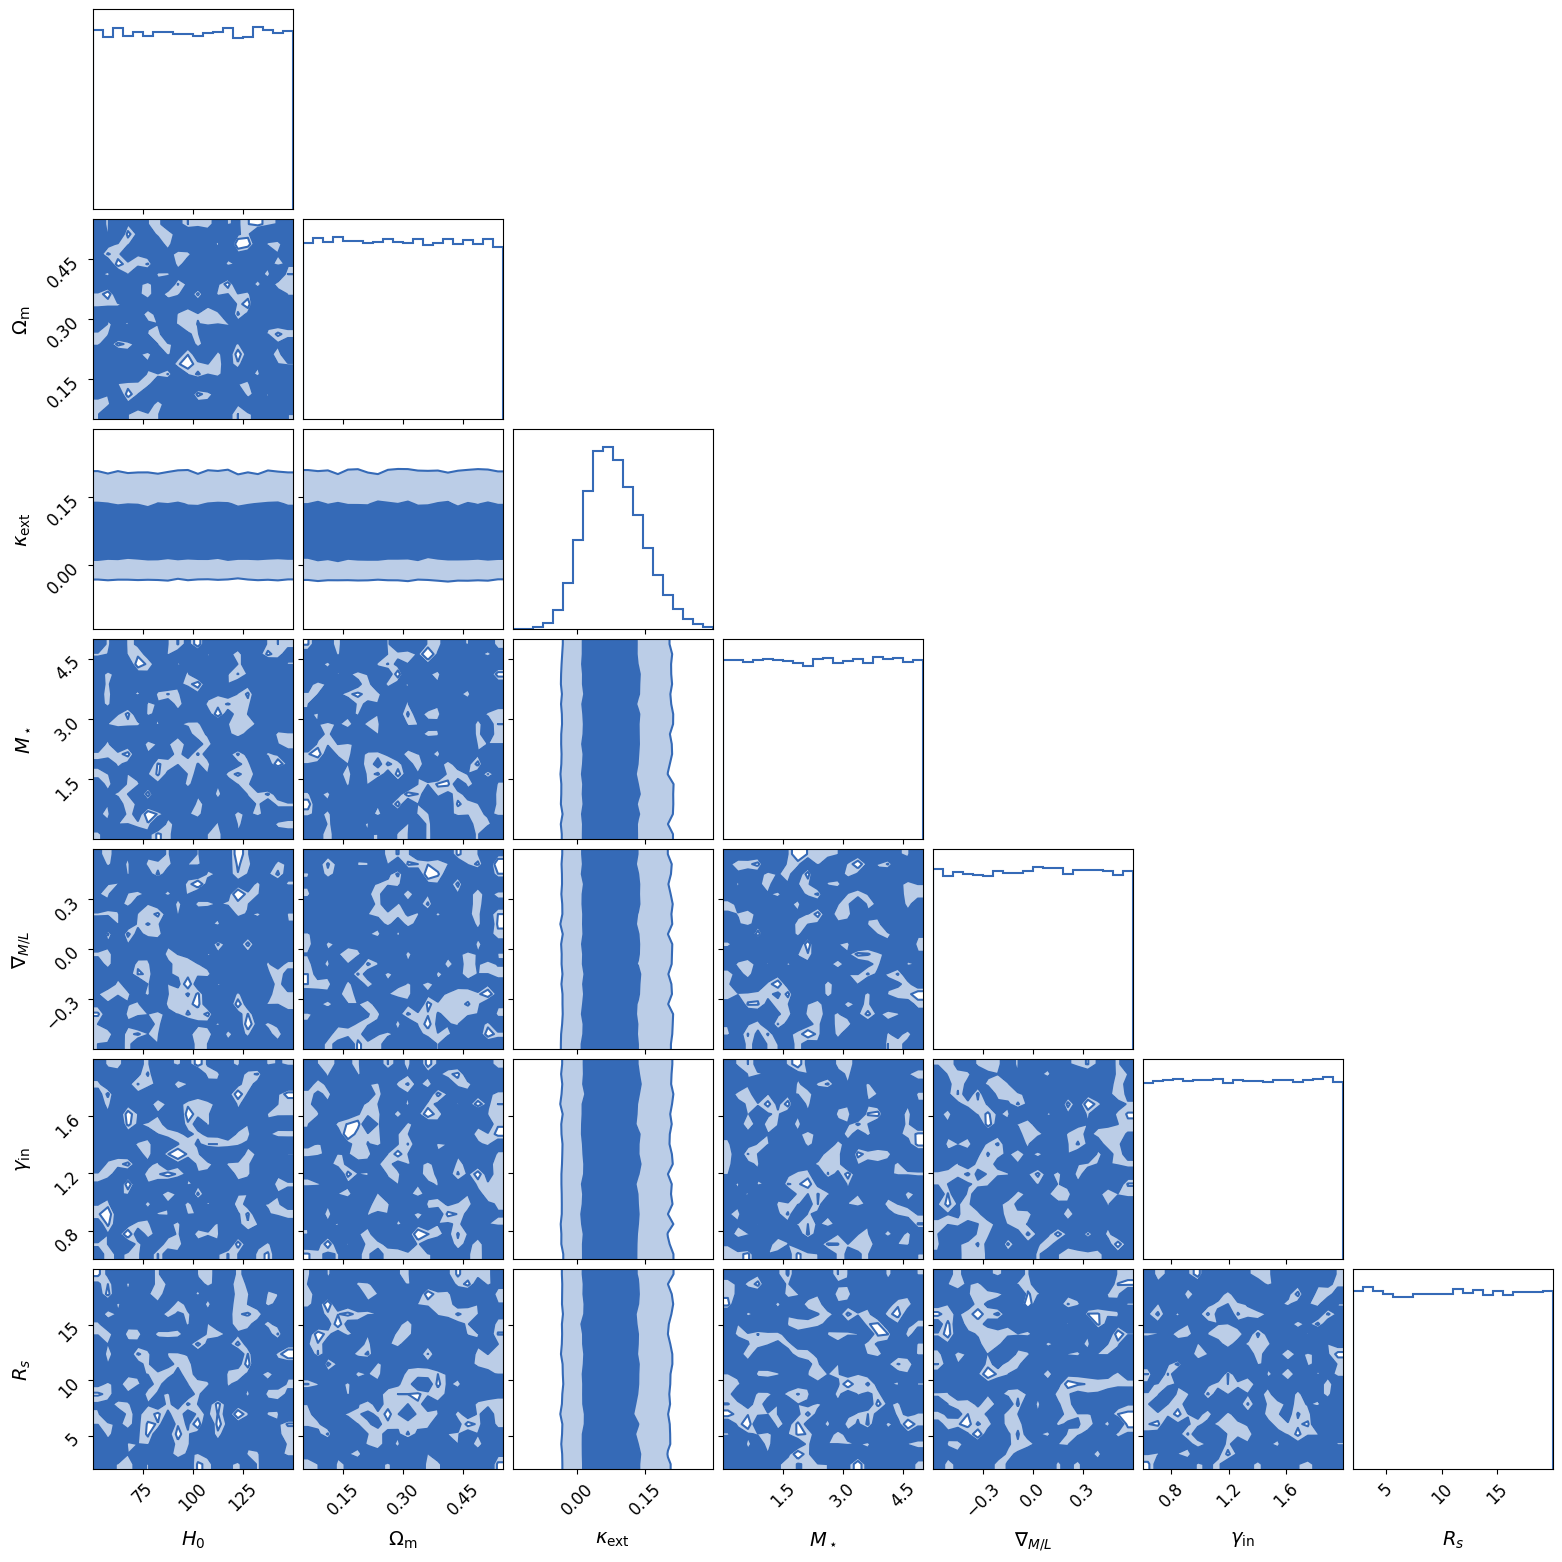

In [5]:
corner_vars = ['H0_cosmo', 'omega_m_cosmo', 'kappa_ext', 'm2l_ratio', 'm2l_ratio_slope', 'gammain_halo', 'Rs_halo']
corner_labels = [r'$H_0$', r'$\Omega_{\rm m}$', r'$\kappa_{\rm ext}$', r'$M_\star$', r'$\nabla_{M/L}$', r'$\gamma_{\rm in}$', r'$R_s$']

if HAVE_CORNER:
    fig = corner.corner(
        prior_samples[corner_vars],
        labels=corner_labels,
        color='#356ab7',
        levels=[0.68, 0.95],
        plot_datapoints=False,
        fill_contours=True,
        hist_kwargs={'density': True, 'histtype': 'step', 'linewidth': 1.5},
        max_n_ticks=4,
    )
    plt.show()
else:
    print('corner is not installed in this kernel; skipping corner plot.')

## Time-delay-only model

This is the actual prior-volume test for H0. The model below mirrors the Step 6 mass, point-source, external-convergence, and cosmology priors, computes the Fermat-potential differences with the same mass-model classes, and applies only the three measured time-delay likelihood terms plus the `kappa_ext_prior`. There is no image-plane likelihood.


In [6]:
RUN_TIME_DELAY_ONLY_MCMC = True
TD_NUM_WARMUP = 1000
TD_NUM_SAMPLES = 3000
TD_NUM_CHAINS = 1
TD_TARGET_ACCEPT = 0.9

try:
    from Tian_infra import import_function
    import_function()

    jax.config.update('jax_enable_x64', True)
    numpyro.enable_x64()

    class CuspyNFWEllipseKappa(MGE):
        def __init__(self):
            super().__init__(
                CuspyNFW_3D_fn,
                'R_s',
                n_gauss=20,
                n_terms=28,
                sigma_start_mult=1/200,
                sigma_end_mult=20,
                three_d=True,
            )

    mass_model_base.STRING_MAPPING['CUSPY_NFW_ELLIPSE_KAPPA'] = CuspyNFWEllipseKappa

    suffix_epl = '_ss=2_fullconcen_light_multimass'
    run_tag = '20260427_14'
    RESULT_DIR = Path(f'./result/result{suffix_epl}_{run_tag}')
    FIXED_FIVE_GAUSS_PATH = RESULT_DIR / f'fixed_five_gaussians_corrected_psf{suffix_epl}.npz'
    fixed_five_gaussians = np.load(FIXED_FIVE_GAUSS_PATH)

    Z_LENS = 0.6575
    Z_SOURCE = 1.662
    ARCSEC_TO_RAD = np.deg2rad(1.0 / 3600.0)
    MPC_TO_KM = 3.0856775814913673e19
    DAY_TO_S = 86400.0
    TIME_DELAY_SCALE_DAYS = MPC_TO_KM * ARCSEC_TO_RAD**2 / (Cosmo.c_km_s * DAY_TO_S)

    TIME_DELAY_OBS = {
        'dt_31_days': {'label': 'B-A1', 'mean': -36.2, 'sigma_minus': 2.3, 'sigma_plus': 1.6},
        'dt_32_days': {'label': 'B-A2', 'mean': -37.3, 'sigma_minus': 3.0, 'sigma_plus': 2.6},
        'dt_34_days': {'label': 'B-C',  'mean': -59.4, 'sigma_minus': 1.3, 'sigma_plus': 1.3},
    }

    G1_MASS_CENTER = (1.556, 1.299)
    G2_MASS_CENTER = (2.145, -3.326)
    G3_MASS_CENTER = (4.243403, 6.185564)
    G7_MASS_CENTER = (-7.284665, -10.319681)
    conj_points = jnp.asarray([
        [1.20212170716053, -0.12271885209256231],
        [0.9053233071260114, 0.5277189685977776],
        [-1.0461673774453952, 1.0081083299749878],
        [-0.1255456241215261, -0.8965524340129204],
    ], dtype=jnp.float64)

    POINT_SOURCE_PRIOR = {'pos_sigma': 0.05, 'pos_window': 0.2, 'log10_amp_low': -3.0, 'log10_amp_high': 4.5}

    mass_model_step6 = MassModel([
        'MULTI_GAUSSIAN_ELLIPSE_KAPPA',
        'CUSPY_NFW_ELLIPSE_KAPPA',
        'SHEAR',
        'SIS',
        'SIS',
        'SIS',
        'SIS',
        'CONVERGENCE',
    ])

    def split_normal_logpdf_jnp(x, mean, sigma_minus, sigma_plus):
        x = jnp.asarray(x, dtype=jnp.float64)
        mean = jnp.asarray(mean, dtype=jnp.float64)
        sigma_minus = jnp.asarray(sigma_minus, dtype=jnp.float64)
        sigma_plus = jnp.asarray(sigma_plus, dtype=jnp.float64)
        sigma = jnp.where(x < mean, sigma_minus, sigma_plus)
        log_norm = jnp.log(jnp.sqrt(2.0 / jnp.pi)) - jnp.log(sigma_minus + sigma_plus)
        return log_norm - 0.5 * ((x - mean) / sigma) ** 2

    def fixed_sis(theta_E, origin):
        return [{'theta_E': theta_E, 'center_x': jnp.asarray(origin[0], dtype=jnp.float64), 'center_y': jnp.asarray(origin[1], dtype=jnp.float64)}]

    def gradient_mass_from_light_td(m2l_ratio, m2l_ratio_slope):
        amp0 = jnp.asarray(fixed_five_gaussians['amp'], dtype=jnp.float64)
        sigma = jnp.asarray(fixed_five_gaussians['sigma'], dtype=jnp.float64)
        ml_gauss = numpyro.deterministic('ml_gauss', m2l_ratio * jnp.power(sigma, m2l_ratio_slope))
        amp = numpyro.deterministic('mass_from_light_amp', amp0 / jnp.sum(amp0) * ml_gauss)
        numpyro.deterministic('total_stellar_mass', jnp.sum(amp))
        return [{
            'amp': amp,
            'sigma': sigma,
            'e1': jnp.asarray(fixed_five_gaussians['e1'], dtype=jnp.float64),
            'e2': jnp.asarray(fixed_five_gaussians['e2'], dtype=jnp.float64),
            'center_x': jnp.asarray(fixed_five_gaussians['center_x'], dtype=jnp.float64),
            'center_y': jnp.asarray(fixed_five_gaussians['center_y'], dtype=jnp.float64),
        }]

    def step6_time_delay_only_model():
        m2l_ratio = numpyro.sample('m2l_ratio', dist.Uniform(0.0, 5.0))
        m2l_ratio_slope = numpyro.sample('m2l_ratio_slope', dist.Uniform(-0.6, 0.6))
        mass_from_light = gradient_mass_from_light_td(m2l_ratio, m2l_ratio_slope)

        Rs_halo = numpyro.sample('Rs_halo', dist.Uniform(2.0, 20.0))
        kappa_s_halo = numpyro.sample('kappa_s_halo', dist.Uniform(0.0, 1.0))
        gammain_halo = numpyro.sample('gammain_halo', dist.Uniform(0.6, 2.0))
        gamma_sheer_halo = numpyro.sample('gamma_sheer_halo', dist.Uniform(-0.5, 0.5).expand([2]).to_event(1))
        e_halo = numpyro.sample('e_halo', dist.TruncatedNormal(0.0, 0.25, low=-0.2, high=0.2).expand([2]).to_event(1))
        center_halo = numpyro.sample('center_halo', dist.TruncatedNormal(0.0, 1.0, low=-0.4, high=0.4).expand([2]).to_event(1))

        gnfw_shear = [{
            'R_s': Rs_halo,
            'gamma': gammain_halo,
            'kappa_s': kappa_s_halo,
            'e1': e_halo[0],
            'e2': e_halo[1],
            'center_x': center_halo[0],
            'center_y': center_halo[1],
        }, {
            'gamma1': gamma_sheer_halo[0],
            'gamma2': gamma_sheer_halo[1],
            'ra_0': center_halo[0],
            'dec_0': center_halo[1],
        }]

        theta_E_g1 = numpyro.sample('theta_E_g1', dist.Uniform(0.0, 0.25))
        theta_E_g2 = numpyro.sample('theta_E_g2', dist.Uniform(0.5, 0.7))
        theta_E_g3 = numpyro.deterministic('theta_E_g3', theta_E_g2 * 0.088 / 0.622)
        theta_E_g7 = numpyro.deterministic('theta_E_g7', theta_E_g2 * 0.388 / 0.622)
        sis_mass = fixed_sis(theta_E_g1, G1_MASS_CENTER) + fixed_sis(theta_E_g2, G2_MASS_CENTER) + fixed_sis(theta_E_g3, G3_MASS_CENTER) + fixed_sis(theta_E_g7, G7_MASS_CENTER)

        kappa_ext = numpyro.sample('kappa_ext', dist.Uniform(-0.20, 0.30))
        numpyro.factor('kappa_ext_prior', split_normal_logpdf_jnp(kappa_ext, 0.059, 0.047, 0.077))
        convergence = [{'kappa': kappa_ext, 'ra_0': jnp.asarray(0.0, dtype=jnp.float64), 'dec_0': jnp.asarray(0.0, dtype=jnp.float64)}]

        ra_ps = numpyro.sample(
            'ra_ps',
            dist.TruncatedNormal(
                loc=conj_points[:, 0],
                scale=POINT_SOURCE_PRIOR['pos_sigma'],
                low=conj_points[:, 0] - POINT_SOURCE_PRIOR['pos_window'],
                high=conj_points[:, 0] + POINT_SOURCE_PRIOR['pos_window'],
            ).to_event(1),
        )
        dec_ps = numpyro.sample(
            'dec_ps',
            dist.TruncatedNormal(
                loc=conj_points[:, 1],
                scale=POINT_SOURCE_PRIOR['pos_sigma'],
                low=conj_points[:, 1] - POINT_SOURCE_PRIOR['pos_window'],
                high=conj_points[:, 1] + POINT_SOURCE_PRIOR['pos_window'],
            ).to_event(1),
        )
        numpyro.sample('log10_amp_ps', dist.Uniform(POINT_SOURCE_PRIOR['log10_amp_low'], POINT_SOURCE_PRIOR['log10_amp_high']).expand([4]).to_event(1))

        kwargs_lens = mass_from_light + gnfw_shear + sis_mass + convergence
        fermat = mass_model_step6.fermat_potential(ra_ps, dec_ps, kwargs_lens)
        numpyro.deterministic('fermat_potential_images', fermat)
        fpd_31 = numpyro.deterministic('fpd_31', fermat[2] - fermat[0])
        fpd_32 = numpyro.deterministic('fpd_32', fermat[2] - fermat[1])
        fpd_34 = numpyro.deterministic('fpd_34', fermat[2] - fermat[3])

        omega_m = numpyro.sample('omega_m_cosmo', dist.Uniform(0.05, 0.55))
        H0 = numpyro.sample('H0_cosmo', dist.Uniform(50.0, 150.0))
        cosmology = {'Omegam': omega_m, 'Omegak': jnp.asarray(0.0, dtype=jnp.float64), 'w0': jnp.asarray(-1.0, dtype=jnp.float64), 'wa': jnp.asarray(0.0, dtype=jnp.float64), 'h0': H0}
        D_dt = numpyro.deterministic('D_dt_Mpc', Cosmo.compute_time_delay_distances(cosmology, Z_LENS, Z_SOURCE))
        prefactor_days = numpyro.deterministic('time_delay_prefactor_days', D_dt * jnp.asarray(TIME_DELAY_SCALE_DAYS, dtype=jnp.float64))

        dt_31 = numpyro.deterministic('dt_31_days', prefactor_days * fpd_31)
        dt_32 = numpyro.deterministic('dt_32_days', prefactor_days * fpd_32)
        dt_34 = numpyro.deterministic('dt_34_days', prefactor_days * fpd_34)
        numpyro.factor('dt_31_like', split_normal_logpdf_jnp(dt_31, TIME_DELAY_OBS['dt_31_days']['mean'], TIME_DELAY_OBS['dt_31_days']['sigma_minus'], TIME_DELAY_OBS['dt_31_days']['sigma_plus']))
        numpyro.factor('dt_32_like', split_normal_logpdf_jnp(dt_32, TIME_DELAY_OBS['dt_32_days']['mean'], TIME_DELAY_OBS['dt_32_days']['sigma_minus'], TIME_DELAY_OBS['dt_32_days']['sigma_plus']))
        numpyro.factor('dt_34_like', split_normal_logpdf_jnp(dt_34, TIME_DELAY_OBS['dt_34_days']['mean'], TIME_DELAY_OBS['dt_34_days']['sigma_minus'], TIME_DELAY_OBS['dt_34_days']['sigma_plus']))

    if RUN_TIME_DELAY_ONLY_MCMC:
        kernel = infer.NUTS(step6_time_delay_only_model, target_accept_prob=TD_TARGET_ACCEPT)
        mcmc_td = infer.MCMC(kernel, num_warmup=TD_NUM_WARMUP, num_samples=TD_NUM_SAMPLES, num_chains=TD_NUM_CHAINS, chain_method='sequential', progress_bar=True)
        mcmc_td.run(jax.random.PRNGKey(RNG_SEED))
        idata_td_only = az.from_numpyro(mcmc_td)
        display(az.summary(idata_td_only, var_names=['H0_cosmo', 'omega_m_cosmo', 'kappa_ext', 'm2l_ratio', 'm2l_ratio_slope', 'kappa_s_halo', 'gammain_halo', 'Rs_halo', 'theta_E_g1', 'theta_E_g2', 'fpd_31', 'fpd_32', 'fpd_34', 'dt_31_days', 'dt_32_days', 'dt_34_days']))
    else:
        print('RUN_TIME_DELAY_ONLY_MCMC=False; set it to True to run the time-delay-only posterior.')
except ImportError as exc:
    print('Required Step 6/JAX/NumPyro dependencies are not available in this kernel.')
    print(repr(exc))


sample: 100%|██████████| 4000/4000 [17:19<00:00,  3.85it/s, 255 steps of size 1.31e-02. acc. prob=0.87] 
arviz - WARNING - Shape validation failed: input_shape: (1, 3000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
H0_cosmo,100.868,24.000,61.504,145.909,0.899,0.403,714.0,1239.0,NaN
omega_m_cosmo,0.302,0.144,0.079,0.549,0.003,0.002,2126.0,1694.0,NaN
kappa_ext,0.061,0.057,-0.042,0.176,0.001,0.001,2343.0,1633.0,NaN
m2l_ratio,2.173,1.241,0.005,4.313,0.040,0.020,867.0,915.0,NaN
m2l_ratio_slope,0.048,0.337,-0.518,0.597,0.009,0.005,1426.0,1159.0,NaN
kappa_s_halo,0.047,0.052,0.000,0.142,0.001,0.002,1225.0,1180.0,NaN
gammain_halo,1.098,0.371,0.600,1.792,0.009,0.006,1714.0,1552.0,NaN
Rs_halo,9.223,5.484,2.001,18.457,0.147,0.089,1774.0,1636.0,NaN
theta_E_g1,0.119,0.072,0.001,0.233,0.001,0.001,2303.0,1449.0,NaN
theta_E_g2,0.585,0.058,0.500,0.684,0.002,0.001,875.0,445.0,NaN


100.91038833680739 23.995933867454617


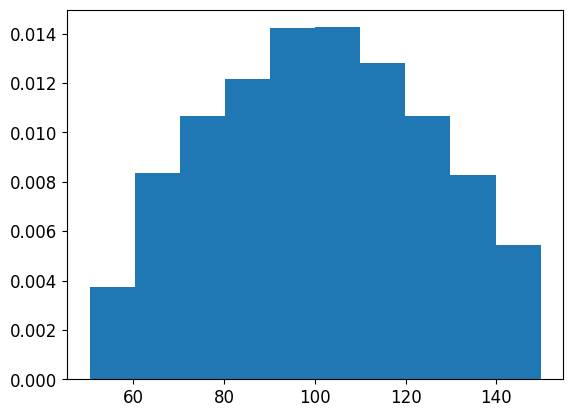

In [18]:
H0_priorvolume_post = np.array(idata_td_only.posterior.H0_cosmo).flatten()
_ = plt.hist(H0_priorvolume_post,density = True)
print(np.median(H0_priorvolume_post), np.std(H0_priorvolume_post))

## Interpretation

The first reference draw shows that `kappa_ext_prior` alone cannot move H0, because it is independent of H0 when the image and time-delay likelihoods are absent. The time-delay-only model is different: it computes Fermat-potential differences from the Step 6 mass and point-source priors, applies the three measured time delays, and samples H0 through the time-delay distance. The resulting H0 posterior is therefore the prior-volume-weighted time-delay-only constraint, not the full imaging+time-delay Step 6 result. Any additional shift between this notebook and the real Step 6 posterior comes from the image-plane likelihood and the way imaging constrains the mass model and Fermat-potential differences.


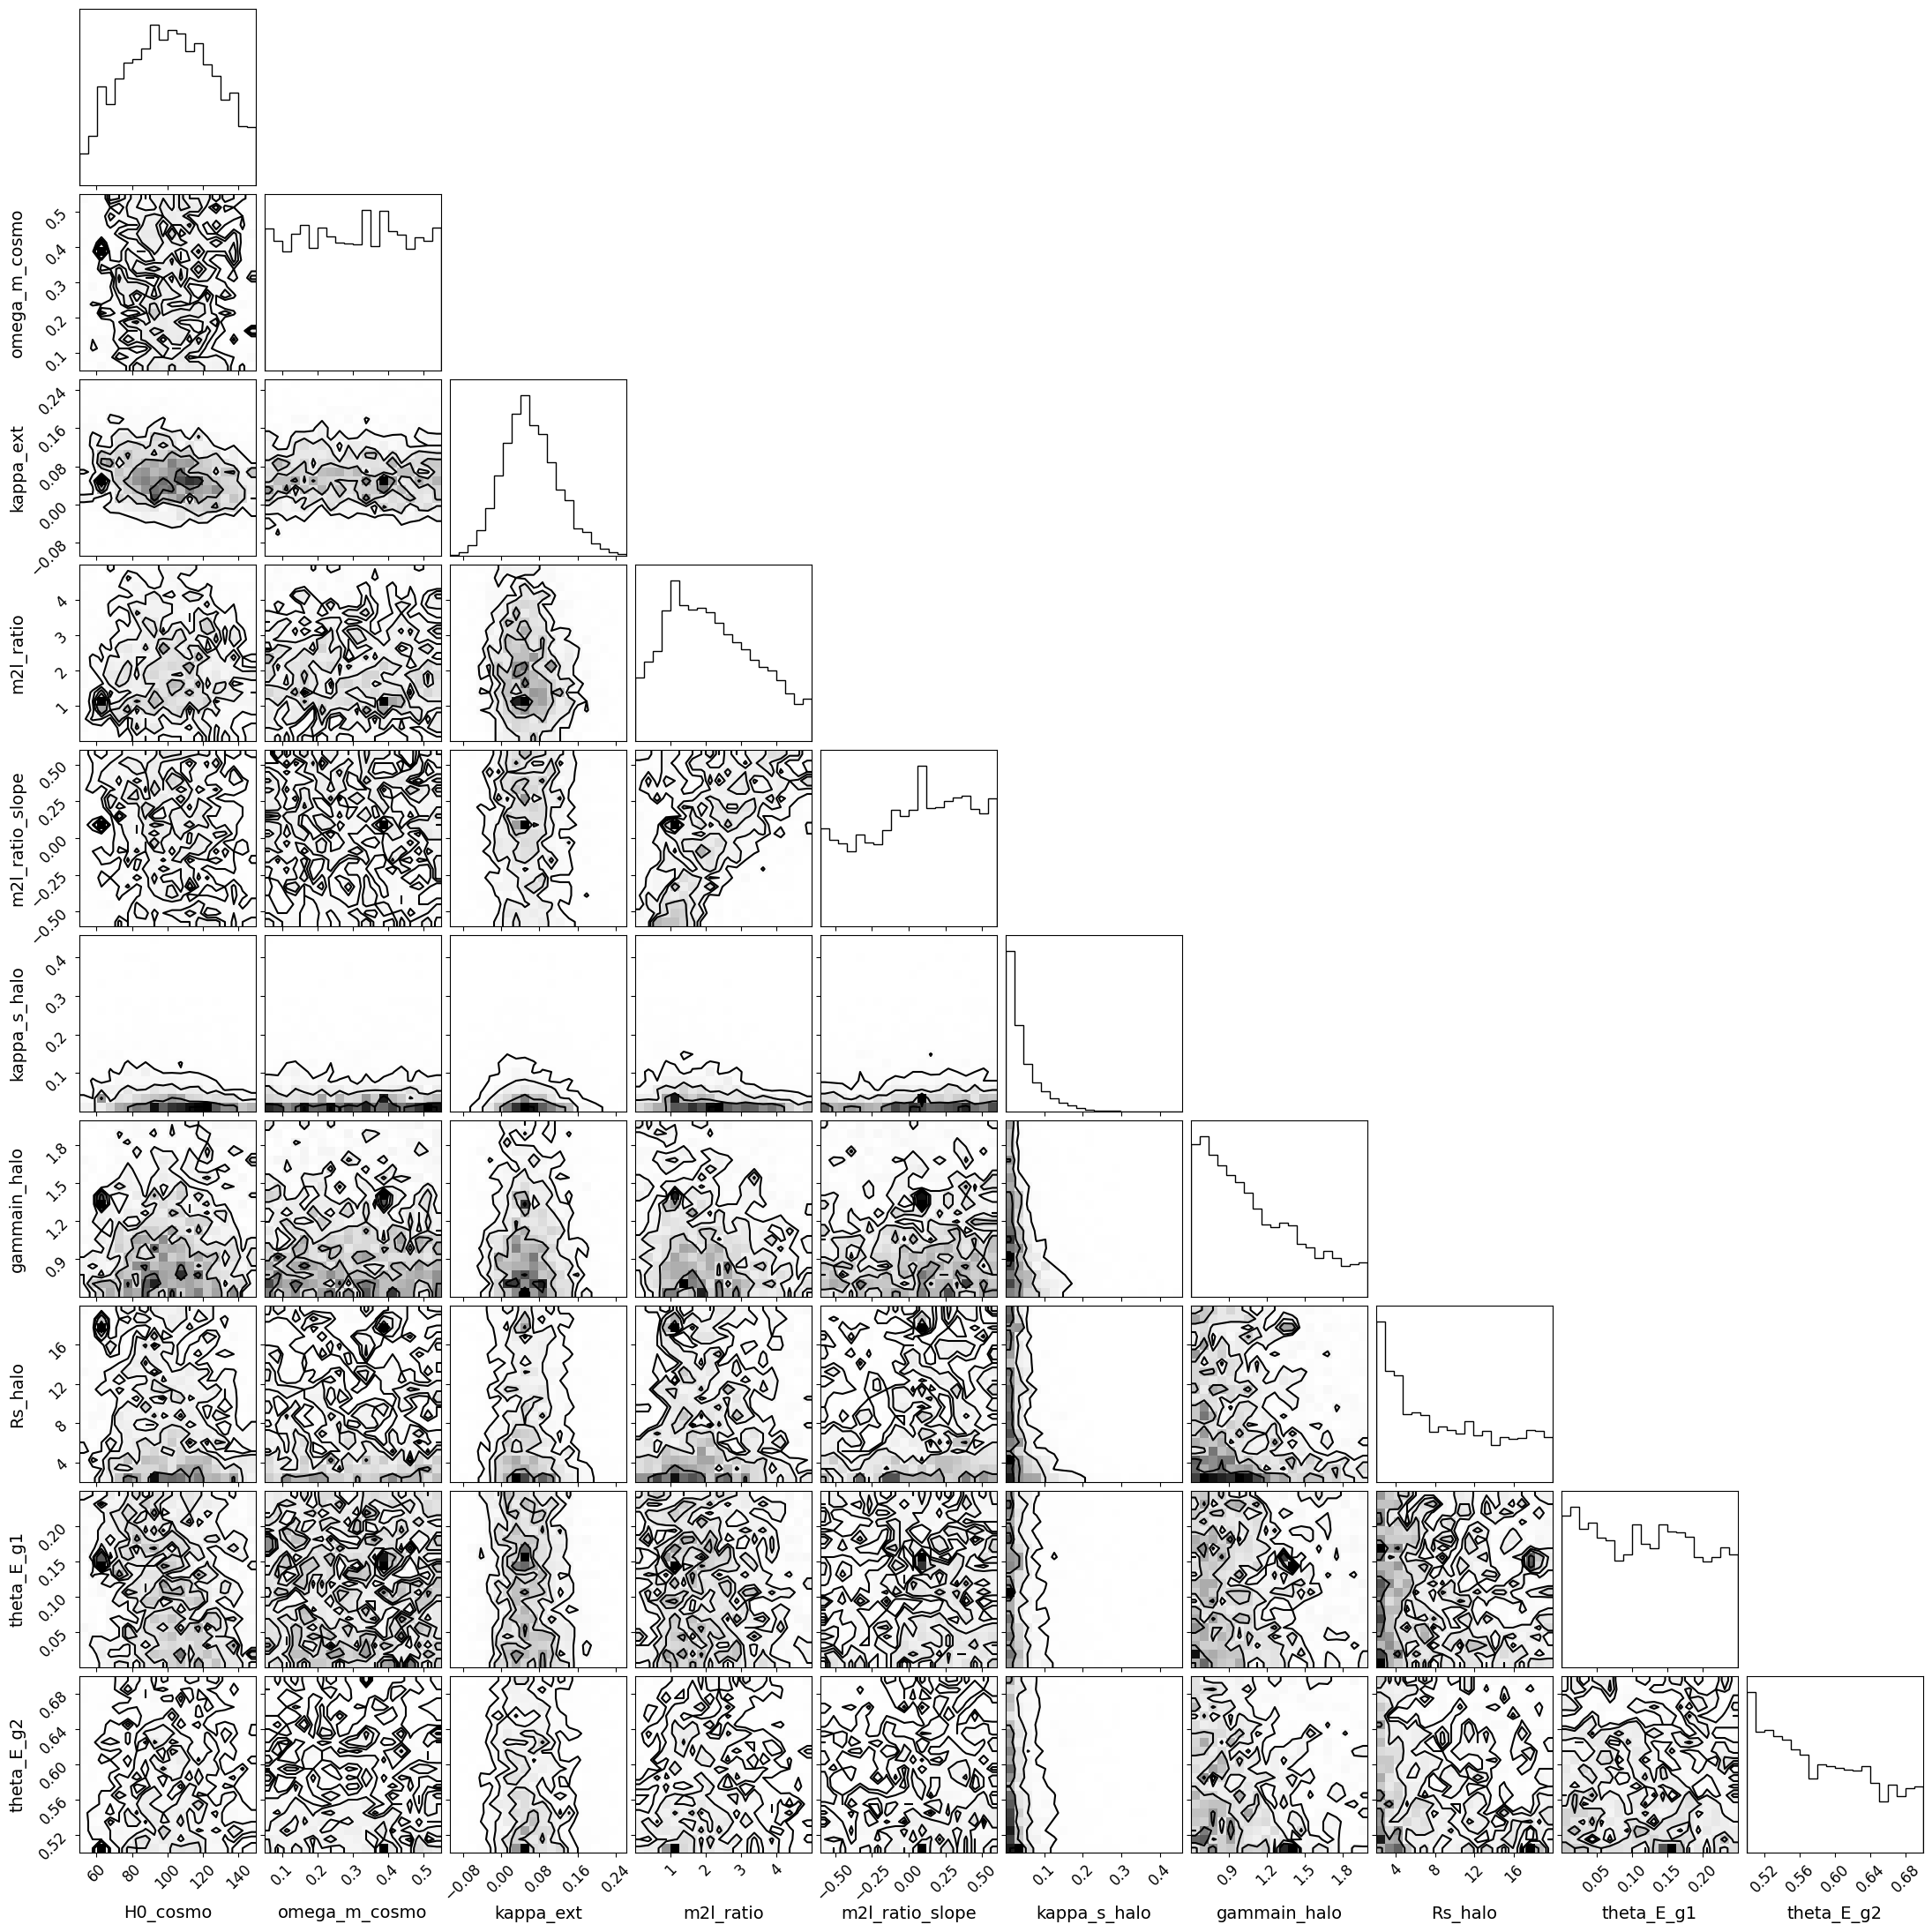

In [22]:
import corner as corner
fig_corner = corner.corner(
    idata_td_only,
    var_names=['H0_cosmo', 'omega_m_cosmo', 'kappa_ext', 'm2l_ratio', 'm2l_ratio_slope', 'kappa_s_halo', 'gammain_halo', 'Rs_halo', 'theta_E_g1', 'theta_E_g2',],
    show_titles=False,
    plot_datapoints=False,
    fill_contours=False,
)
plt.show()
